# 05 — Prepayment Model: PSA + Rate-Dependent CPR

Spec §6. Data source: `panel_logistic_2021_2025.parquet` (reuse; 2021–2025 originations).

This window is chosen specifically because the 2021 refinancing boom and 2022 CPR
collapse capture the widest rate variation available for characterizing prepayment.

Pipeline:
1. Load 2021-2025 panel, filter to FRM loans only
2. Compute scheduled principal and unscheduled prepayment (annuity formula)
3. Compute pool-level CPR time series
4. Fit PSA scalar speed k
5. Plot observed CPR vs. 100% PSA schedule
6. Demonstrate rate-dependent CPR responds correctly to refinancing incentive

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
from dotenv import load_dotenv

# NOTE: select the pyenv "Python 3 (ipykernel)" kernel, not the anaconda one.
load_dotenv()
sys.path.insert(0, str(Path('..') / 'src'))
import prepayment as pp

PROCESSED = Path('..') / 'data' / 'processed'
FIGURES   = Path('..') / 'artifacts' / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)

## 1. Load precomputed monthly pool CPR (FRM loans)

Scheduled principal, prepayment, and the pool-level CPR aggregation across the
329M-row FRM panel are computed out-of-core with DuckDB by
`python src/build_model_aggregates.py` (replicating
`prepayment.compute_scheduled_principal` + `prepayment.pool_cpr`). Here we load
only the resulting ~60-row monthly series — the full panel will not fit in a
16 GB kernel.

In [2]:
monthly_path = PROCESSED / 'pool_cpr_monthly.parquet'
if not monthly_path.exists():
    raise FileNotFoundError(
        f'{monthly_path} not found. First run:\n'
        '    python src/build_model_aggregates.py'
    )
monthly = pd.read_parquet(monthly_path)
monthly['date'] = pd.to_datetime(monthly['reporting_period'].astype(str), format='%Y%m')
monthly = monthly.sort_values('date').reset_index(drop=True)
print(f'Monthly pool CPR series: {len(monthly)} periods '
      f'({monthly.date.min():%Y-%m} – {monthly.date.max():%Y-%m})')
monthly.head()

Monthly pool CPR series: 59 periods (2020-11 – 2025-09)


,reporting_period,beg_bal,sched_p,prepay,smm,cpr,date
0,202011,5.660000e+05,6.698485e+02,0.000000e+00,0.000000,0.000000,2020-11-01
1,202012,1.159168e+11,2.621358e+08,1.242829e+08,0.001075,0.012819,2020-12-01
2,202101,2.376932e+11,5.348988e+08,3.176335e+08,0.001339,0.015954,2021-01-01
3,202102,3.521470e+11,7.970892e+08,4.635979e+08,0.001319,0.015719,2021-02-01
4,202103,4.678568e+11,1.067518e+09,7.386254e+08,0.001582,0.018824,2021-03-01


## 2. Sanity checks and pool-level CPR time series (spec §6.2)

In [3]:
# Sanity checks on the aggregated monthly series
print('Sanity checks:')
print(f'  Periods with negative scheduled principal: {(monthly.sched_p < 0).sum()} (expect 0)')
print(f'  Periods with negative prepayment:          {(monthly.prepay < 0).sum()} (expect 0)')
print(f'  Periods with CPR < 0:                      {(monthly.cpr < 0).sum()} (expect 0)')
total_prepay = monthly['prepay'].sum()
total_sched  = monthly['sched_p'].sum()
print(f'\n  Total prepayment:          ${total_prepay/1e9:.2f}B')
print(f'  Total scheduled principal: ${total_sched/1e9:.2f}B')
print(f'  Prepay/Sched ratio:        {total_prepay/total_sched:.2f}x')

Sanity checks:
  Periods with negative scheduled principal: 0 (expect 0)
  Periods with negative prepayment:          0 (expect 0)
  Periods with CPR < 0:                      0 (expect 0)

  Total prepayment:          $94.31B
  Total scheduled principal: $198.61B
  Prepay/Sched ratio:        0.47x


## 3. CPR summary statistics

In [4]:
print(f'CPR range: {monthly.cpr.min():.4f} – {monthly.cpr.max():.4f}')
print(f'Mean CPR:  {monthly.cpr.mean():.4f} ({monthly.cpr.mean()*100:.2f}%)')
print(f'Mean SMM:  {monthly.smm.mean():.5f}')
monthly[['reporting_period', 'beg_bal', 'sched_p', 'prepay', 'smm', 'cpr']].describe().round(4)

CPR range: 0.0000 – 0.0188
Mean CPR:  0.0125 (1.25%)
Mean SMM:  0.00105


,reporting_period,beg_bal,sched_p,prepay,smm,cpr
count,59.0000,5.900000e+01,5.900000e+01,5.900000e+01,59.0000,59.0000
mean,202286.1017,1.557416e+12,3.366231e+09,1.598555e+09,0.0010,0.0125
std,145.3150,5.575577e+11,1.136946e+09,5.913867e+08,0.0003,0.0030
min,202011.0000,5.660000e+05,6.698485e+02,0.000000e+00,0.0000,0.0000
25%,202201.5000,1.374801e+12,3.155278e+09,1.358373e+09,0.0009,0.0107
50%,202304.0000,1.730220e+12,3.795822e+09,1.556222e+09,0.0010,0.0123
75%,202406.5000,1.944259e+12,4.092628e+09,1.943001e+09,0.0012,0.0147
max,202509.0000,2.147554e+12,4.423344e+09,2.841157e+09,0.0016,0.0188


## 4. Fit PSA scalar speed (spec §6.3)

In [5]:
psa_k = pp.fit_psa_speed(monthly)
print(f'Pool equivalent PSA speed: {psa_k*100:.1f}% PSA')
print(f'(100% PSA = benchmark; >100% = faster than benchmark prepayment)')

Pool equivalent PSA speed: 22.6% PSA
(100% PSA = benchmark; >100% = faster than benchmark prepayment)


## 5. Plot observed CPR vs. PSA schedule

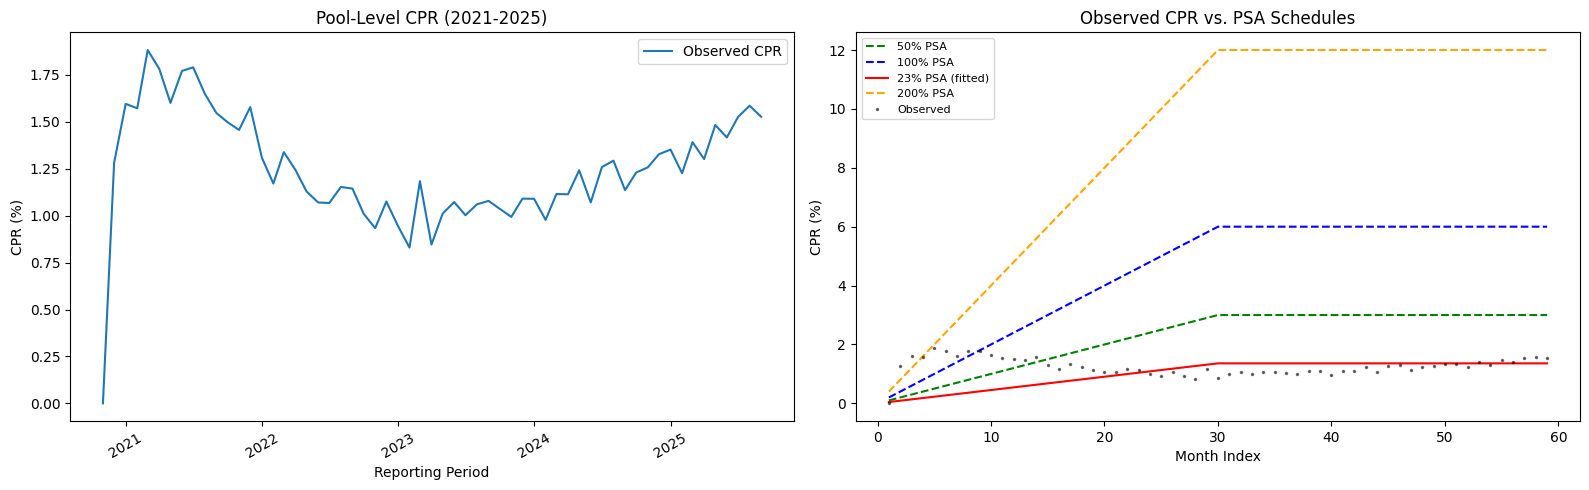

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: time series of observed pool CPR
axes[0].plot(monthly['date'], monthly['cpr'] * 100, label='Observed CPR', linewidth=1.5)
axes[0].set_title('Pool-Level CPR (2021-2025)')
axes[0].set_xlabel('Reporting Period')
axes[0].set_ylabel('CPR (%)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend()

# Right: observed CPR vs. PSA schedules at various speeds
months_seq = np.arange(1, len(monthly) + 1)
for speed, color in [(0.5, 'green'), (1.0, 'blue'), (psa_k, 'red'), (2.0, 'orange')]:
    label = f'{speed*100:.0f}% PSA' + (' (fitted)' if abs(speed - psa_k) < 0.01 else '')
    axes[1].plot(
        months_seq,
        pp.psa_cpr_schedule(months_seq, speed) * 100,
        label=label, linestyle='--' if speed != psa_k else '-',
        color=color, linewidth=1.5
    )
axes[1].plot(months_seq[:len(monthly)], monthly['cpr'].values * 100,
             'k.', markersize=3, alpha=0.5, label='Observed')
axes[1].set_title('Observed CPR vs. PSA Schedules')
axes[1].set_xlabel('Month Index')
axes[1].set_ylabel('CPR (%)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES / 'prepayment_cpr_vs_psa.png', bbox_inches='tight')
plt.show()

## 6. Rate-dependent CPR: verify response to refinancing incentive (spec §6.4)

Higher RI (borrower coupon > market rate) → more refinancing → higher CPR.  
At RI = 0 (at-the-money), pool prepays at approximately 100% PSA.

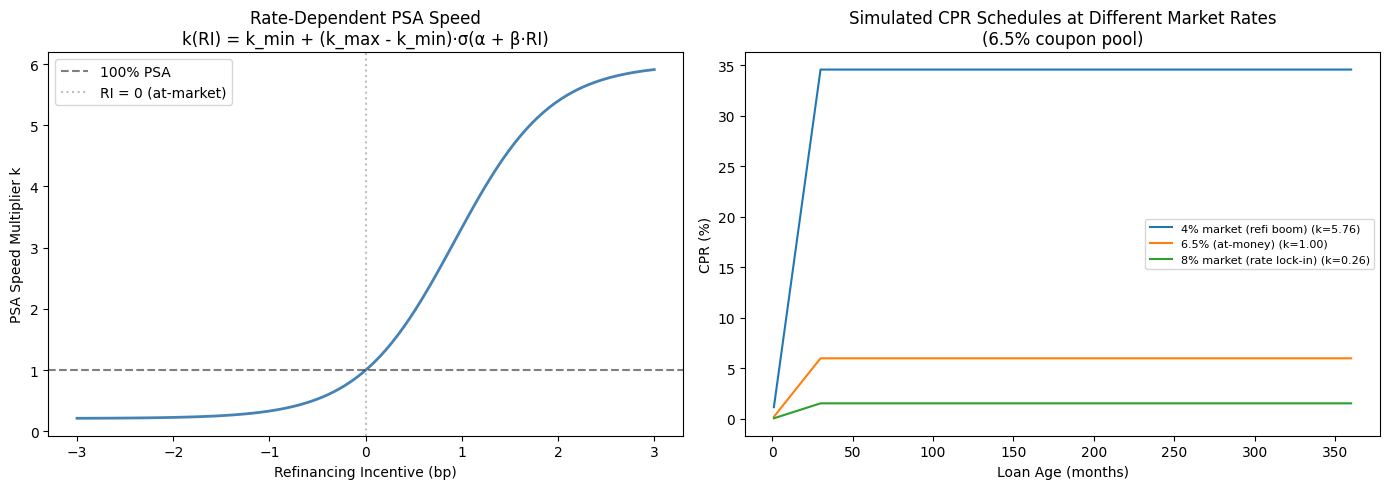


Verification: higher RI → higher CPR
  market=4.0%  RI=+2.5bp  k=5.763  plateau CPR=34.58%
  market=6.5%  RI=+0.0bp  k=0.998  plateau CPR=5.99%
  market=8.0%  RI=-1.5bp  k=0.255  plateau CPR=1.53%


In [7]:
ri_range = np.linspace(-0.03, 0.03, 100)  # -300bp to +300bp
k_vals   = pp.rate_dependent_psa_k(ri_range)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: PSA speed vs. refinancing incentive
axes[0].plot(ri_range * 100, k_vals, 'steelblue', linewidth=2)
axes[0].axhline(1.0, color='k', linestyle='--', alpha=0.5, label='100% PSA')
axes[0].axvline(0, color='gray', linestyle=':', alpha=0.5, label='RI = 0 (at-market)')
axes[0].set_xlabel('Refinancing Incentive (bp)')
axes[0].set_ylabel('PSA Speed Multiplier k')
axes[0].set_title('Rate-Dependent PSA Speed\nk(RI) = k_min + (k_max - k_min)·σ(α + β·RI)')
axes[0].legend()

# Right: resulting CPR at different rate scenarios for a 6.5% coupon pool
coupon = 0.065
for market_rate, label in [(0.04, '4% market (refi boom)'), (0.065, '6.5% (at-money)'),
                            (0.08, '8% market (rate lock-in)')]:
    months_sim = np.arange(1, 361)
    ri_scenario = coupon - market_rate
    k_scenario = pp.rate_dependent_psa_k(np.array([ri_scenario]))[0]
    cpr_sim = pp.psa_cpr_schedule(months_sim, k_scenario)
    axes[1].plot(months_sim, cpr_sim * 100, label=f'{label} (k={k_scenario:.2f})', linewidth=1.5)

axes[1].set_title('Simulated CPR Schedules at Different Market Rates\n(6.5% coupon pool)')
axes[1].set_xlabel('Loan Age (months)')
axes[1].set_ylabel('CPR (%)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES / 'prepayment_rate_dependent_cpr.png', bbox_inches='tight')
plt.show()

print('\nVerification: higher RI → higher CPR')
for market_rate in [0.04, 0.065, 0.08]:
    ri = coupon - market_rate
    k_val = pp.rate_dependent_psa_k(np.array([ri]))[0]
    print(f'  market={market_rate*100:.1f}%  RI={ri*100:+.1f}bp  k={k_val:.3f}  plateau CPR={k_val*0.06*100:.2f}%')